# Hybrid Beam Forming using a Multilayer Perceptron 

## Load Helpers 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import json 
import torch 
import torch.nn as nn 
from torch.utils.data import DataLoader, random_split 

import mitsuba as mi
mi.set_variant("cuda_ad_mono_polarized")
# mi.set_variant("llvm_ad_rgb"); 

from sionna.rt import PathSolver

import os 
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "scripts")); 
sys.path.append(str(Path.cwd().parent / "outputs")); 
from dataset_handler import DatasetHandler 
from mlp import MLP 
from generate_raynet_dataset_v3 import (
    CONFIG,
    setup_scene,
    make_tx_positions,
    make_candidate_configs,
    sample_two_users_for_target_class,
    trace_four_links,
    score_all_joint_configs,
    target_class_passes,
    thermal_noise_watts,
    dbm_to_watts,
) 

### Parameters 

In [2]:
MODEL_CONFIG = {
    "input": 8, 
    "h1_dim": 128, 
    "h2_dim": 128, 
    "h3_dim": 64, 
    "out_1": len(CONFIG["sector_angles_deg"]),
    "out_2": CONFIG["num_codebooks"]
}; 

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu"); 
print(f"Device: {DEVICE}"); 

BATCH_SIZE = 32; 
EPOCHS = 100; 
LR = 1e-2; 
lr_str = str(LR).replace("0.", ""); 

Device: cuda


## Train MLP 

Epoch [1/100] Loss: 3.2903
Epoch [2/100] Loss: 2.8595
Epoch [3/100] Loss: 2.7933
Epoch [4/100] Loss: 2.7387
Epoch [5/100] Loss: 2.7030
Epoch [6/100] Loss: 2.6917
Epoch [7/100] Loss: 2.6826
Epoch [8/100] Loss: 2.6544
Epoch [9/100] Loss: 2.6460
Epoch [10/100] Loss: 2.6343
Epoch [11/100] Loss: 2.6259
Epoch [12/100] Loss: 2.6237
Epoch [13/100] Loss: 2.6225
Epoch [14/100] Loss: 2.6046
Epoch [15/100] Loss: 2.6027
Epoch [16/100] Loss: 2.6183
Epoch [17/100] Loss: 2.6062
Epoch [18/100] Loss: 2.6049
Epoch [19/100] Loss: 2.6129
Epoch [20/100] Loss: 2.5964
Epoch [21/100] Loss: 2.6095
Epoch [22/100] Loss: 2.5999
Epoch [23/100] Loss: 2.5998
Epoch [24/100] Loss: 2.5879
Epoch [25/100] Loss: 2.6008
Epoch [26/100] Loss: 2.5896
Epoch [27/100] Loss: 2.6020
Epoch [28/100] Loss: 2.5896
Epoch [29/100] Loss: 2.5897
Epoch [30/100] Loss: 2.5904
Epoch [31/100] Loss: 2.5930
Epoch [32/100] Loss: 2.6001
Epoch [33/100] Loss: 2.5897
Epoch [34/100] Loss: 2.5983
Epoch [35/100] Loss: 2.5995
Epoch [36/100] Loss: 2.5975
E

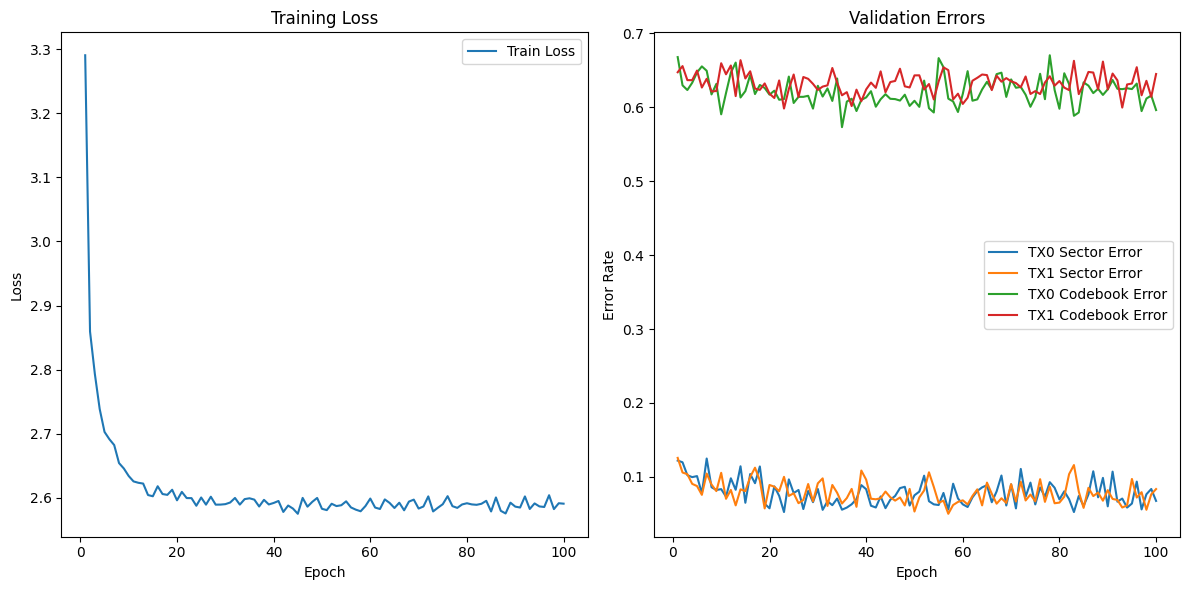

Epoch [1/100] Loss: 3.2657
Epoch [2/100] Loss: 2.8470
Epoch [3/100] Loss: 2.7414
Epoch [4/100] Loss: 2.6915
Epoch [5/100] Loss: 2.6298
Epoch [6/100] Loss: 2.5648
Epoch [7/100] Loss: 2.5203
Epoch [8/100] Loss: 2.4640
Epoch [9/100] Loss: 2.4171
Epoch [10/100] Loss: 2.3706
Epoch [11/100] Loss: 2.3081
Epoch [12/100] Loss: 2.3106
Epoch [13/100] Loss: 2.2486
Epoch [14/100] Loss: 2.2482
Epoch [15/100] Loss: 2.2419
Epoch [16/100] Loss: 2.2113
Epoch [17/100] Loss: 2.1840
Epoch [18/100] Loss: 2.1823
Epoch [19/100] Loss: 2.1727
Epoch [20/100] Loss: 2.1686
Epoch [21/100] Loss: 2.1827
Epoch [22/100] Loss: 2.1597
Epoch [23/100] Loss: 2.1338
Epoch [24/100] Loss: 2.1312
Epoch [25/100] Loss: 2.1458
Epoch [26/100] Loss: 2.1303
Epoch [27/100] Loss: 2.1225
Epoch [28/100] Loss: 2.1183
Epoch [29/100] Loss: 2.1212
Epoch [30/100] Loss: 2.0949
Epoch [31/100] Loss: 2.1326
Epoch [32/100] Loss: 2.1085
Epoch [33/100] Loss: 2.1012
Epoch [34/100] Loss: 2.0998
Epoch [35/100] Loss: 2.0817
Epoch [36/100] Loss: 2.1047
E

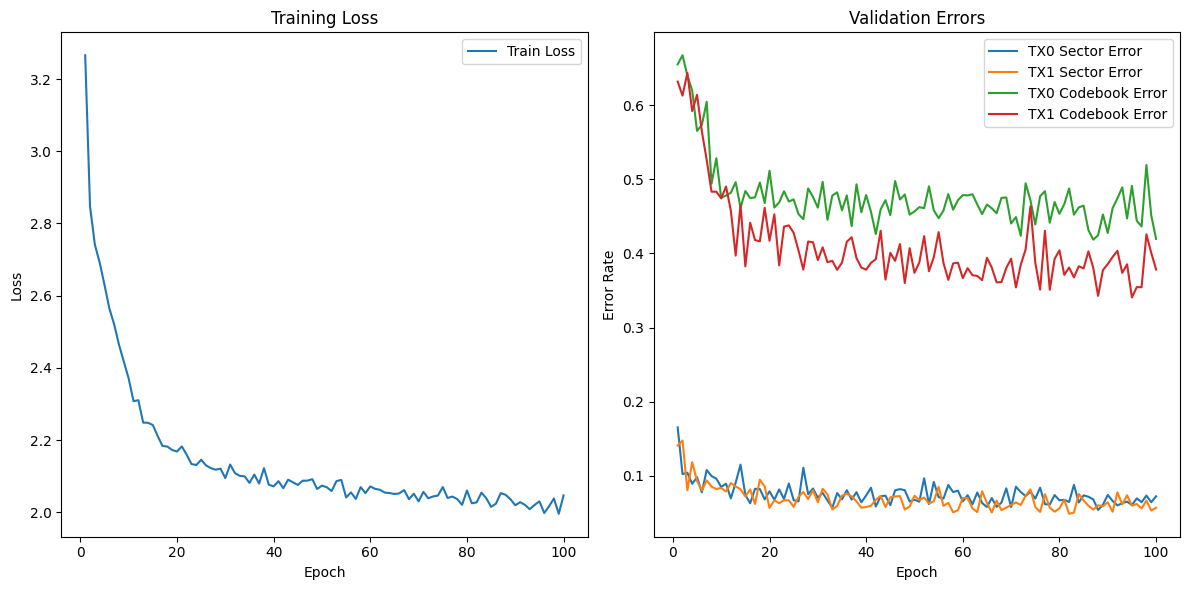

Epoch [1/100] Loss: 3.3437
Epoch [2/100] Loss: 2.8171
Epoch [3/100] Loss: 2.7399
Epoch [4/100] Loss: 2.6719
Epoch [5/100] Loss: 2.6160
Epoch [6/100] Loss: 2.5805
Epoch [7/100] Loss: 2.5112
Epoch [8/100] Loss: 2.4887
Epoch [9/100] Loss: 2.3805
Epoch [10/100] Loss: 2.3317
Epoch [11/100] Loss: 2.2737
Epoch [12/100] Loss: 2.2167
Epoch [13/100] Loss: 2.1807
Epoch [14/100] Loss: 2.1280
Epoch [15/100] Loss: 2.1236
Epoch [16/100] Loss: 2.0575
Epoch [17/100] Loss: 2.0476
Epoch [18/100] Loss: 2.0497
Epoch [19/100] Loss: 2.0170
Epoch [20/100] Loss: 1.9866
Epoch [21/100] Loss: 1.9937
Epoch [22/100] Loss: 1.9612
Epoch [23/100] Loss: 1.9898
Epoch [24/100] Loss: 1.9412
Epoch [25/100] Loss: 1.9155
Epoch [26/100] Loss: 1.9166
Epoch [27/100] Loss: 1.9281
Epoch [28/100] Loss: 1.9135
Epoch [29/100] Loss: 1.9065
Epoch [30/100] Loss: 1.8909
Epoch [31/100] Loss: 1.8853
Epoch [32/100] Loss: 1.8804
Epoch [33/100] Loss: 1.8610
Epoch [34/100] Loss: 1.8527
Epoch [35/100] Loss: 1.8473
Epoch [36/100] Loss: 1.8457
E

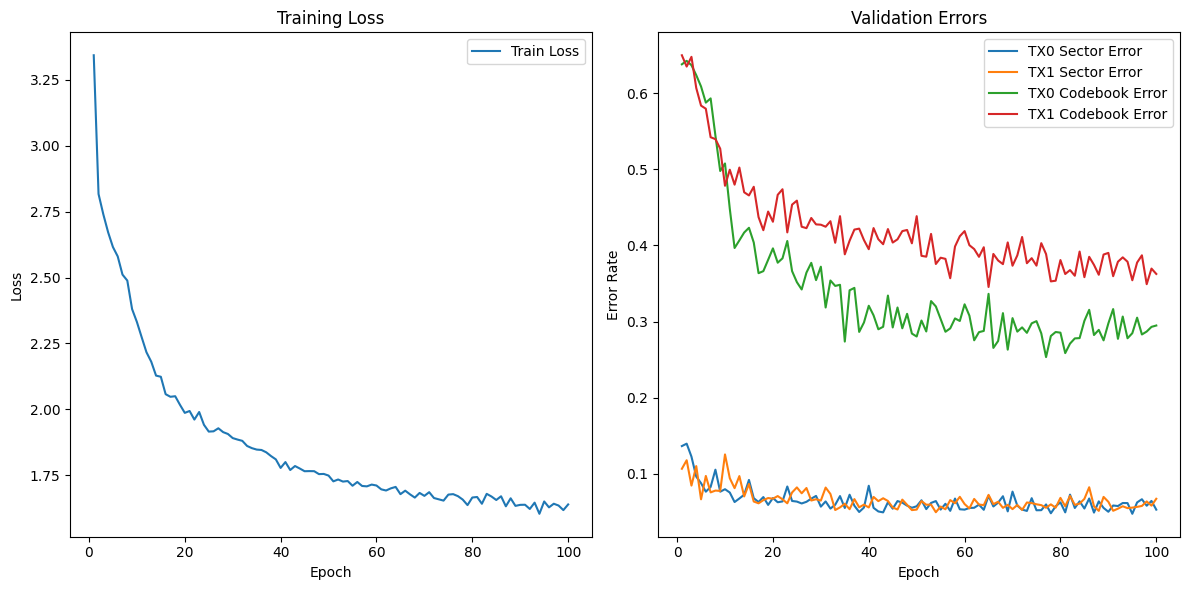

Epoch [1/100] Loss: 3.1984
Epoch [2/100] Loss: 2.7231
Epoch [3/100] Loss: 2.5856
Epoch [4/100] Loss: 2.4908
Epoch [5/100] Loss: 2.3356
Epoch [6/100] Loss: 2.1581
Epoch [7/100] Loss: 1.9753
Epoch [8/100] Loss: 1.8282
Epoch [9/100] Loss: 1.6964
Epoch [10/100] Loss: 1.6049
Epoch [11/100] Loss: 1.5184
Epoch [12/100] Loss: 1.4445
Epoch [13/100] Loss: 1.3816
Epoch [14/100] Loss: 1.3021
Epoch [15/100] Loss: 1.2603
Epoch [16/100] Loss: 1.2236
Epoch [17/100] Loss: 1.1553
Epoch [18/100] Loss: 1.1341
Epoch [19/100] Loss: 1.0993
Epoch [20/100] Loss: 1.0868
Epoch [21/100] Loss: 1.0636
Epoch [22/100] Loss: 1.0489
Epoch [23/100] Loss: 1.0360
Epoch [24/100] Loss: 1.0240
Epoch [25/100] Loss: 1.0125
Epoch [26/100] Loss: 0.9969
Epoch [27/100] Loss: 0.9930
Epoch [28/100] Loss: 0.9862
Epoch [29/100] Loss: 0.9722
Epoch [30/100] Loss: 0.9710
Epoch [31/100] Loss: 0.9555
Epoch [32/100] Loss: 0.9553
Epoch [33/100] Loss: 0.9382
Epoch [34/100] Loss: 0.9575
Epoch [35/100] Loss: 0.9412
Epoch [36/100] Loss: 0.9220
E

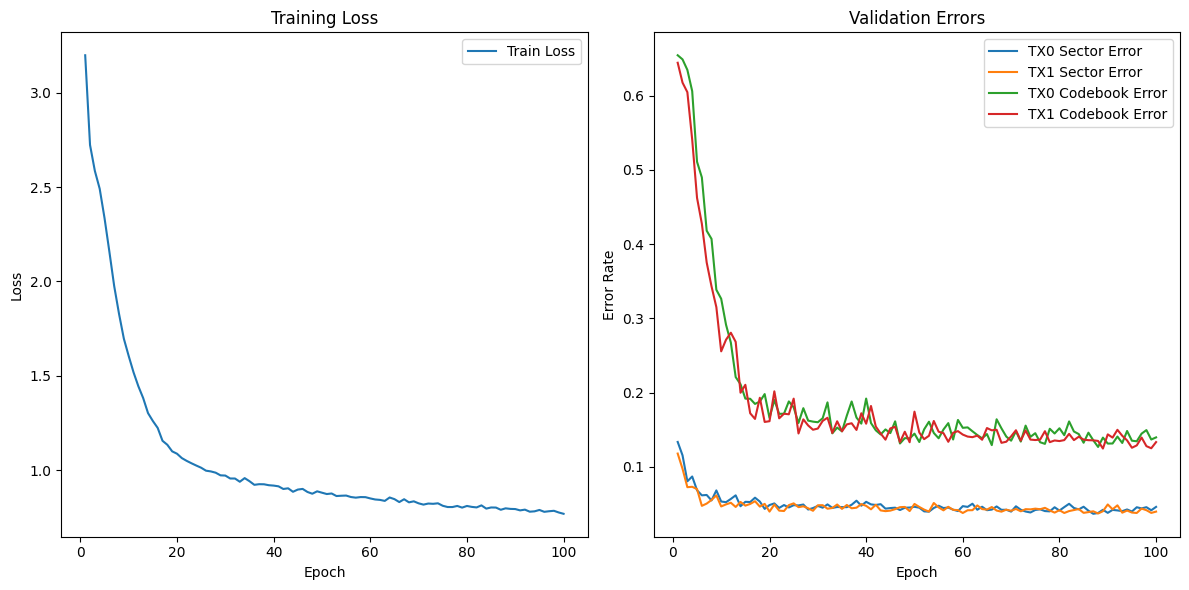

Epoch [1/100] Loss: 3.3525
Epoch [2/100] Loss: 2.7811
Epoch [3/100] Loss: 2.6592
Epoch [4/100] Loss: 2.5602
Epoch [5/100] Loss: 2.4859
Epoch [6/100] Loss: 2.4037
Epoch [7/100] Loss: 2.3183
Epoch [8/100] Loss: 2.2052
Epoch [9/100] Loss: 2.0938
Epoch [10/100] Loss: 1.9814
Epoch [11/100] Loss: 1.8539
Epoch [12/100] Loss: 1.7395
Epoch [13/100] Loss: 1.6566
Epoch [14/100] Loss: 1.5984
Epoch [15/100] Loss: 1.5235
Epoch [16/100] Loss: 1.4807
Epoch [17/100] Loss: 1.4141
Epoch [18/100] Loss: 1.3744
Epoch [19/100] Loss: 1.3520
Epoch [20/100] Loss: 1.3143
Epoch [21/100] Loss: 1.2890
Epoch [22/100] Loss: 1.2721
Epoch [23/100] Loss: 1.2548
Epoch [24/100] Loss: 1.2181
Epoch [25/100] Loss: 1.2034
Epoch [26/100] Loss: 1.1779
Epoch [27/100] Loss: 1.1616
Epoch [28/100] Loss: 1.1228
Epoch [29/100] Loss: 1.1108
Epoch [30/100] Loss: 1.1064
Epoch [31/100] Loss: 1.0854
Epoch [32/100] Loss: 1.0846
Epoch [33/100] Loss: 1.0467
Epoch [34/100] Loss: 1.0657
Epoch [35/100] Loss: 1.0314
Epoch [36/100] Loss: 1.0224
E

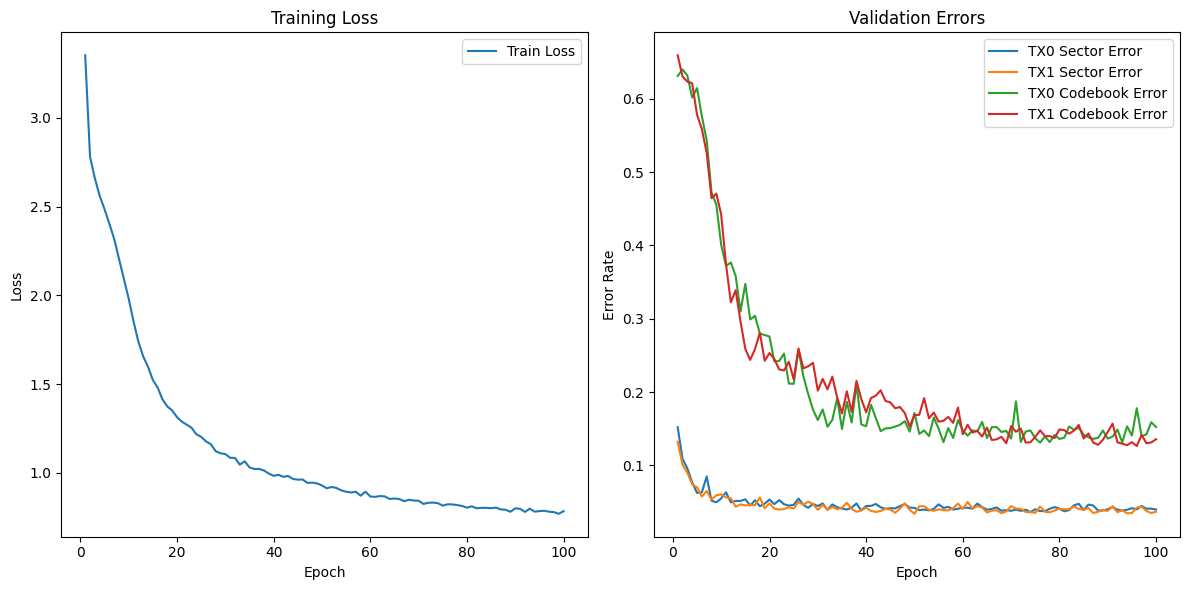

Epoch [1/100] Loss: 3.5717
Epoch [2/100] Loss: 2.8595
Epoch [3/100] Loss: 2.7368
Epoch [4/100] Loss: 2.6790
Epoch [5/100] Loss: 2.6056
Epoch [6/100] Loss: 2.5355
Epoch [7/100] Loss: 2.4913
Epoch [8/100] Loss: 2.4590
Epoch [9/100] Loss: 2.4186
Epoch [10/100] Loss: 2.3862
Epoch [11/100] Loss: 2.3566
Epoch [12/100] Loss: 2.3083
Epoch [13/100] Loss: 2.2632
Epoch [14/100] Loss: 2.2150
Epoch [15/100] Loss: 2.1795
Epoch [16/100] Loss: 2.1336
Epoch [17/100] Loss: 2.0907
Epoch [18/100] Loss: 2.0540
Epoch [19/100] Loss: 2.0021
Epoch [20/100] Loss: 1.9573
Epoch [21/100] Loss: 1.9224
Epoch [22/100] Loss: 1.8810
Epoch [23/100] Loss: 1.8325
Epoch [24/100] Loss: 1.7837
Epoch [25/100] Loss: 1.7325
Epoch [26/100] Loss: 1.7055
Epoch [27/100] Loss: 1.6419
Epoch [28/100] Loss: 1.5981
Epoch [29/100] Loss: 1.5653
Epoch [30/100] Loss: 1.5160
Epoch [31/100] Loss: 1.4880
Epoch [32/100] Loss: 1.4608
Epoch [33/100] Loss: 1.4160
Epoch [34/100] Loss: 1.3956
Epoch [35/100] Loss: 1.3639
Epoch [36/100] Loss: 1.3330
E

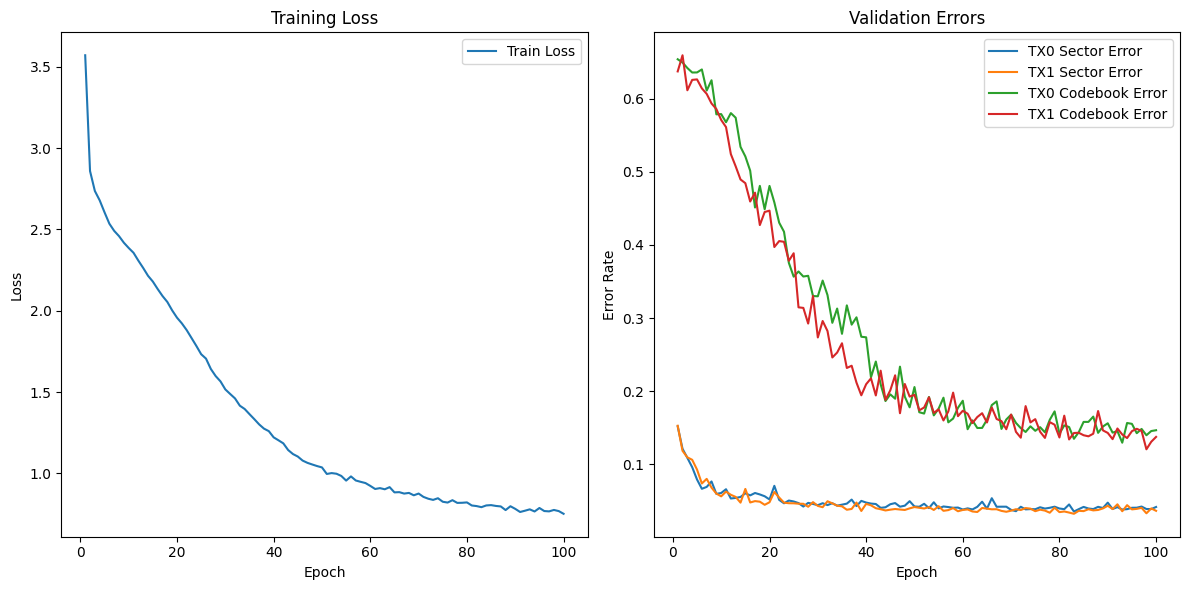

Epoch [1/100] Loss: 4.1729
Epoch [2/100] Loss: 3.2469
Epoch [3/100] Loss: 2.9787
Epoch [4/100] Loss: 2.8629
Epoch [5/100] Loss: 2.7869
Epoch [6/100] Loss: 2.7375
Epoch [7/100] Loss: 2.6961
Epoch [8/100] Loss: 2.6693
Epoch [9/100] Loss: 2.6452
Epoch [10/100] Loss: 2.6246
Epoch [11/100] Loss: 2.6061
Epoch [12/100] Loss: 2.5894
Epoch [13/100] Loss: 2.5730
Epoch [14/100] Loss: 2.5574
Epoch [15/100] Loss: 2.5391
Epoch [16/100] Loss: 2.5239
Epoch [17/100] Loss: 2.5050
Epoch [18/100] Loss: 2.4865
Epoch [19/100] Loss: 2.4704
Epoch [20/100] Loss: 2.4501
Epoch [21/100] Loss: 2.4298
Epoch [22/100] Loss: 2.4077
Epoch [23/100] Loss: 2.3868
Epoch [24/100] Loss: 2.3631
Epoch [25/100] Loss: 2.3412
Epoch [26/100] Loss: 2.3271
Epoch [27/100] Loss: 2.3107
Epoch [28/100] Loss: 2.2919
Epoch [29/100] Loss: 2.2779
Epoch [30/100] Loss: 2.2658
Epoch [31/100] Loss: 2.2512
Epoch [32/100] Loss: 2.2371
Epoch [33/100] Loss: 2.2229
Epoch [34/100] Loss: 2.2091
Epoch [35/100] Loss: 2.1960
Epoch [36/100] Loss: 2.1836
E

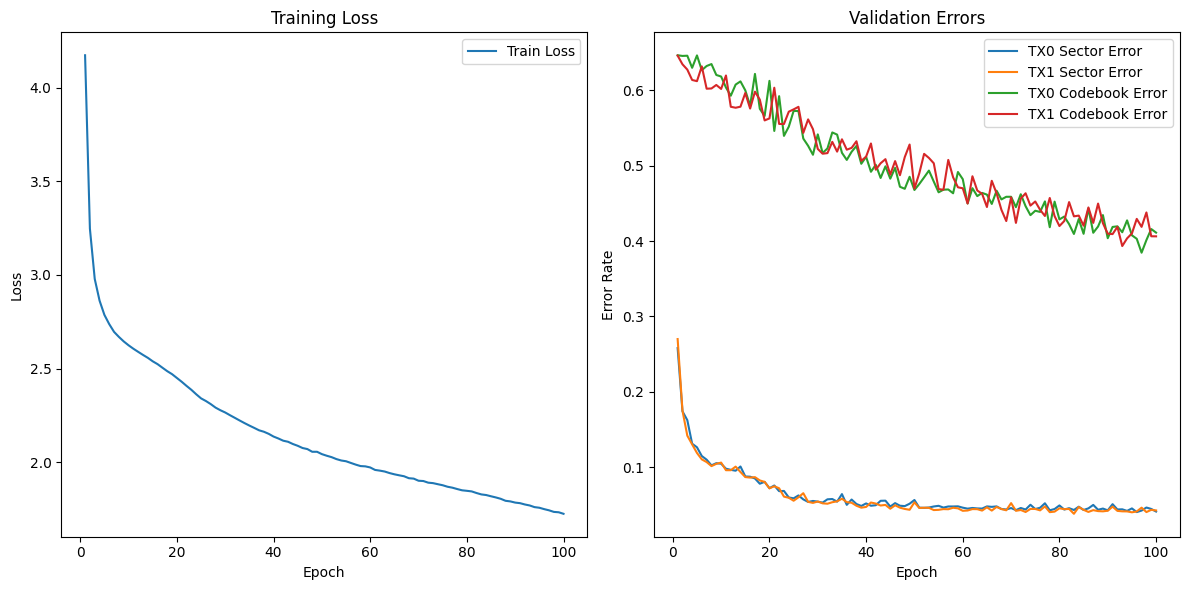

Epoch [1/100] Loss: 4.4298
Epoch [2/100] Loss: 3.4973
Epoch [3/100] Loss: 3.1848
Epoch [4/100] Loss: 3.0117
Epoch [5/100] Loss: 2.9124
Epoch [6/100] Loss: 2.8427
Epoch [7/100] Loss: 2.7932
Epoch [8/100] Loss: 2.7524
Epoch [9/100] Loss: 2.7206
Epoch [10/100] Loss: 2.6936
Epoch [11/100] Loss: 2.6674
Epoch [12/100] Loss: 2.6513
Epoch [13/100] Loss: 2.6277
Epoch [14/100] Loss: 2.6110
Epoch [15/100] Loss: 2.5970
Epoch [16/100] Loss: 2.5838
Epoch [17/100] Loss: 2.5686
Epoch [18/100] Loss: 2.5579
Epoch [19/100] Loss: 2.5417
Epoch [20/100] Loss: 2.5313
Epoch [21/100] Loss: 2.5226
Epoch [22/100] Loss: 2.5078
Epoch [23/100] Loss: 2.4961
Epoch [24/100] Loss: 2.4843
Epoch [25/100] Loss: 2.4700
Epoch [26/100] Loss: 2.4589
Epoch [27/100] Loss: 2.4457
Epoch [28/100] Loss: 2.4321
Epoch [29/100] Loss: 2.4175
Epoch [30/100] Loss: 2.4036
Epoch [31/100] Loss: 2.3901
Epoch [32/100] Loss: 2.3773
Epoch [33/100] Loss: 2.3626
Epoch [34/100] Loss: 2.3505
Epoch [35/100] Loss: 2.3378
Epoch [36/100] Loss: 2.3236
E

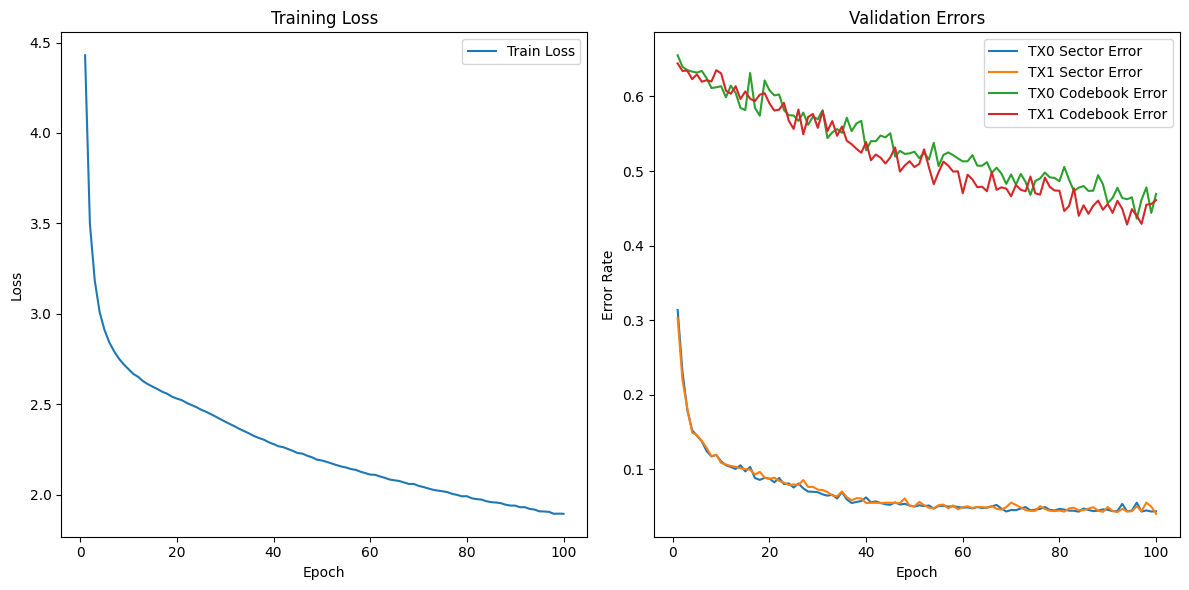

Epoch [1/100] Loss: 4.9490
Epoch [2/100] Loss: 3.8320
Epoch [3/100] Loss: 3.4390
Epoch [4/100] Loss: 3.1930
Epoch [5/100] Loss: 3.0372
Epoch [6/100] Loss: 2.9382
Epoch [7/100] Loss: 2.8723
Epoch [8/100] Loss: 2.8194
Epoch [9/100] Loss: 2.7806
Epoch [10/100] Loss: 2.7444
Epoch [11/100] Loss: 2.7187
Epoch [12/100] Loss: 2.6916
Epoch [13/100] Loss: 2.6708
Epoch [14/100] Loss: 2.6562
Epoch [15/100] Loss: 2.6392
Epoch [16/100] Loss: 2.6267
Epoch [17/100] Loss: 2.6136
Epoch [18/100] Loss: 2.6041
Epoch [19/100] Loss: 2.5915
Epoch [20/100] Loss: 2.5818
Epoch [21/100] Loss: 2.5728
Epoch [22/100] Loss: 2.5650
Epoch [23/100] Loss: 2.5556
Epoch [24/100] Loss: 2.5499
Epoch [25/100] Loss: 2.5379
Epoch [26/100] Loss: 2.5345
Epoch [27/100] Loss: 2.5256
Epoch [28/100] Loss: 2.5167
Epoch [29/100] Loss: 2.5099
Epoch [30/100] Loss: 2.5029
Epoch [31/100] Loss: 2.4946
Epoch [32/100] Loss: 2.4870
Epoch [33/100] Loss: 2.4803
Epoch [34/100] Loss: 2.4712
Epoch [35/100] Loss: 2.4647
Epoch [36/100] Loss: 2.4563
E

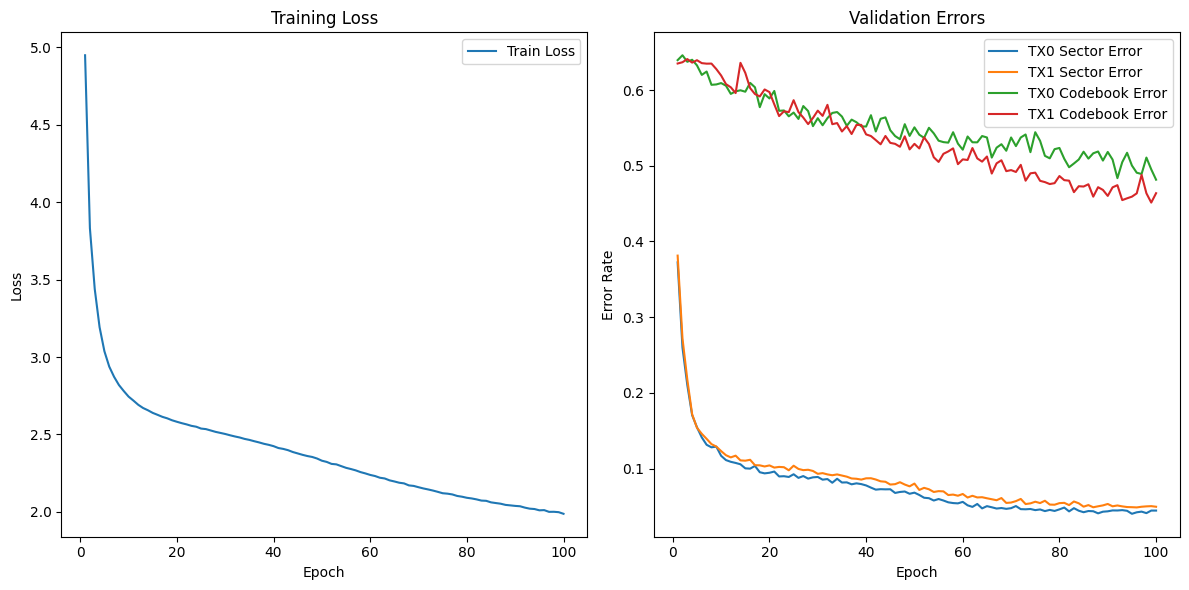

In [3]:
def plot_training_curves(train_losses, val_metrics, model_name): # Helper to plot train loss and validation error 

    epochs = range(1, len(train_losses) + 1); 

    plt.figure(figsize=(12, 6)); 

    # Train loss
    plt.subplot(1, 2, 1); 
    plt.plot(epochs, train_losses, label = "Train Loss"); 
    plt.xlabel("Epoch"); 
    plt.ylabel("Loss"); 
    plt.title("Training Loss"); 
    plt.legend(); 

    # Validation error 
    plt.subplot(1, 2, 2); 
    plt.plot(epochs, val_metrics["tx0_sector"], label = "TX0 Sector Error"); 
    plt.plot(epochs, val_metrics["tx1_sector"], label = "TX1 Sector Error"); 
    plt.plot(epochs, val_metrics["tx0_codebook"], label = "TX0 Codebook Error"); 
    plt.plot(epochs, val_metrics["tx1_codebook"], label = "TX1 Codebook Error"); 

    plt.xlabel("Epoch"); 
    plt.ylabel("Error Rate"); 
    plt.title("Validation Errors"); 
    plt.legend(); 

    plt.tight_layout(); 
    plt_path = f"../figures/{model_name}_loss_curves.png"; 
    plt.savefig(plt_path); 
    plt.show(); 
    plt.close(); 


def train(trainset, model_name): 

    dataset = DatasetHandler(trainset); 

    train_size = int(0.8 * len(dataset)); 
    val_size = len(dataset) - train_size; 

    train_set, val_set = random_split(
        dataset,
        [train_size, val_size]
    ); 

    train_loader = DataLoader(
        train_set,
        batch_size = BATCH_SIZE,
        shuffle = True
    ); 

    val_loader = DataLoader(
        val_set,
        batch_size = BATCH_SIZE,
        shuffle = False
    ); 

    model = MLP(
        input = MODEL_CONFIG["input"],
        h1_dim = MODEL_CONFIG["h1_dim"],
        h2_dim = MODEL_CONFIG["h2_dim"],
        h3_dim = MODEL_CONFIG["h3_dim"],
        out_1 = MODEL_CONFIG["out_1"],
        out_2 = MODEL_CONFIG["out_2"],
    ).to(DEVICE); 

    criterion = nn.CrossEntropyLoss(); 

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr = LR
    ); 

    train_losses = []; 

    val_tx0_sector = []; 
    val_tx1_sector = []; 
    val_tx0_codebook = []; 
    val_tx1_codebook = []; 

    for epoch in range(EPOCHS):

        model.train(); 

        running_loss = 0.0; 

        for (
            x,
            tx0_sector,
            tx1_sector,
            tx0_codebook,
            tx1_codebook
        ) in train_loader:

            x = x.to(DEVICE); 

            tx0_sector = tx0_sector.to(DEVICE); 
            tx1_sector = tx1_sector.to(DEVICE); 

            tx0_codebook = tx0_codebook.to(DEVICE); 
            tx1_codebook = tx1_codebook.to(DEVICE); 

            optimizer.zero_grad(); 

            s0, s1, c0, c1 = model(x); 

            loss_s0 = criterion(s0, tx0_sector); 
            loss_s1 = criterion(s1, tx1_sector); 

            loss_c0 = criterion(c0, tx0_codebook); 
            loss_c1 = criterion(c1, tx1_codebook); 

            loss = (
                loss_s0
                + loss_s1
                + loss_c0
                + loss_c1
            ); 

            loss.backward(); 
            optimizer.step(); 

            running_loss += loss.item(); 

        avg_train_loss = running_loss / len(train_loader); 
        train_losses.append(avg_train_loss); 

        print(
            f"Epoch [{epoch + 1}/{EPOCHS}] "
            f"Loss: {avg_train_loss:.4f}"
        ); 

        # Test on validation set 
        model.eval(); 

        correct_tx0_s = 0; 
        total_tx0_s = 0; 

        correct_tx1_s = 0; 
        total_tx1_s = 0; 

        correct_tx0_c = 0; 
        total_tx0_c = 0; 

        correct_tx1_c = 0; 
        total_tx1_c = 0; 

        with torch.no_grad(): 
            for (
                x,
                tx0_sector,
                tx1_sector,
                tx0_codebook,
                tx1_codebook
            ) in val_loader: 

                x = x.to(DEVICE); 
                tx0_sector = tx0_sector.to(DEVICE); 
                tx1_sector = tx1_sector.to(DEVICE); 
                tx0_codebook = tx0_codebook.to(DEVICE); 
                tx1_codebook = tx1_codebook.to(DEVICE); 

                s0, s1, c0, c1 = model(x); 

                pred_s0 = torch.argmax(s0, dim = 1); 
                pred_s1 = torch.argmax(s1, dim = 1); 
                pred_c0 = torch.argmax(c0, dim = 1); 
                pred_c1 = torch.argmax(c1, dim = 1); 

                correct_tx0_s += (pred_s0 == tx0_sector).sum().item(); 
                correct_tx1_s += (pred_s1 == tx1_sector).sum().item(); 
                correct_tx0_c += (pred_c0 == tx0_codebook).sum().item(); 
                correct_tx1_c += (pred_c1 == tx1_codebook).sum().item(); 

                total_tx0_s += tx0_sector.size(0); 
                total_tx1_s += tx1_sector.size(0); 
                total_tx0_c += tx0_codebook.size(0); 
                total_tx1_c += tx1_codebook.size(0); 

        # Compute validation error rates
        val_tx0_sector.append(1 - correct_tx0_s / total_tx0_s); 
        val_tx1_sector.append(1 - correct_tx1_s / total_tx1_s); 
        val_tx0_codebook.append(1 - correct_tx0_c / total_tx0_c); 
        val_tx1_codebook.append(1 - correct_tx1_c / total_tx1_c); 


    torch.save(
        model.state_dict(),
        f"../models/{model_name}.pth" 
    ); 

    model_info = {
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LR,
    
        "architecture": {
            "input_dim": MODEL_CONFIG["input"],
            "h1_dim": MODEL_CONFIG["h1_dim"],
            "h2_dim": MODEL_CONFIG["h2_dim"],
            "h3_dim": MODEL_CONFIG["h3_dim"],
            "out_1": MODEL_CONFIG["out_1"],
            "out_2": MODEL_CONFIG["out_2"],
        } 
    };

    with open(f"../models/{model_name}.json", "w") as f:
        json.dump(model_info, f, indent = 4);

    print("Model saved."); 

    val_metrics = {
        "tx0_sector": val_tx0_sector,
        "tx1_sector": val_tx1_sector,
        "tx0_codebook": val_tx0_codebook,
        "tx1_codebook": val_tx1_codebook,
    }; 

    plot_training_curves(train_losses, val_metrics, model_name); 

bs_list = [32, 64, 128]; 
lr_list = [1e-2, 1e-3, 1e-4]; 

for i in range(len(lr_list)): 
    for j in range(len(bs_list)): 
        LR = lr_list[i]; 
        BATCH_SIZE = bs_list[j]; 
        train("../Datasets/dataset_8sector_3book_full_100.csv", f"mlp_{i * 3 + j}"); 


## Test MLP

In [4]:
def test(testset): 

    dataset = DatasetHandler(testset); 

    loader = DataLoader(
        dataset,
        batch_size = BATCH_SIZE, 
        shuffle = False
    ); 

    model = MLP(
        input = MODEL_CONFIG["input"],
        h1_dim = MODEL_CONFIG["h1_dim"],
        h2_dim = MODEL_CONFIG["h2_dim"],
        h3_dim = MODEL_CONFIG["h3_dim"],
        out_1 = MODEL_CONFIG["out_1"],
        out_2 = MODEL_CONFIG["out_2"],
    ).to(DEVICE); 

    model.load_state_dict(
        torch.load(
            f"../models/mlp_0.pth", 
            map_location = DEVICE
        )
    ); 

    model.to(DEVICE); 
    model.eval(); 

    correct_s0 = 0; 
    correct_s1 = 0; 

    correct_c0 = 0; 
    correct_c1 = 0; 

    total = 0; 

    with torch.no_grad():

        for (
            x,
            tx0_sector,
            tx1_sector,
            tx0_codebook,
            tx1_codebook
        ) in loader:

            x = x.to(DEVICE); 

            s0, s1, c0, c1 = model(x); 

            pred_s0 = torch.argmax(s0, dim = 1); 
            pred_s1 = torch.argmax(s1, dim = 1); 

            pred_c0 = torch.argmax(c0, dim = 1); 
            pred_c1 = torch.argmax(c1, dim = 1); 

            correct_s0 += (
                pred_s0.cpu() == tx0_sector
            ).sum().item(); 

            correct_s1 += (
                pred_s1.cpu() == tx1_sector
            ).sum().item(); 

            correct_c0 += (
                pred_c0.cpu() == tx0_codebook
            ).sum().item(); 

            correct_c1 += (
                pred_c1.cpu() == tx1_codebook
            ).sum().item(); 

            total += x.size(0); 

    print(
        f"TX0 Sector Accuracy: "
        f"{100 * correct_s0 / total:.2f}%"
    ); 

    print(
        f"TX1 Sector Accuracy: "
        f"{100 * correct_s1 / total:.2f}%"
    ); 

    print(
        f"TX0 Codebook Accuracy: "
        f"{100 * correct_c0 / total:.2f}%"
    ); 

    print(
        f"TX1 Codebook Accuracy: "
        f"{100 * correct_c1 / total:.2f}%"
    ); 

test("../Datasets/dataset_test_3book_full_10.csv"); 

TX0 Sector Accuracy: 93.06%
TX1 Sector Accuracy: 92.09%
TX0 Codebook Accuracy: 40.52%
TX1 Codebook Accuracy: 35.61%


## Test MLP on Random User Pairs 
Generate two users in an environment and check if our MLP can determine the proper configuration to give the users the required throughput and maintain a sufficient signal to noise ratio. 

In [ ]:
def test_single_pair(model, scene, solver, candidates, verbose = False): 
    tx0_pos, tx1_pos = make_tx_positions(); 
    rng = np.random.default_rng(); 

    # Generate two random users 
    tx0_target = rng.choice(CONFIG["sector_angles_deg"]); 
    tx1_target = rng.choice(CONFIG["sector_angles_deg"]); 

    users = sample_two_users_for_target_class(
        rng,
        tx0_target_angle=tx0_target,
        tx1_target_angle=tx1_target,
    ); 

    if users is None:
        return None; 

    users["u1_required_rate_bpshz"] = rng.uniform(1, 5); 
    users["u2_required_rate_bpshz"] = rng.uniform(1, 5); 

    links = trace_four_links(
        scene = scene,
        p_solver = solver,
        tx0_pos = tx0_pos,
        tx1_pos = tx1_pos,
        users = users,
        sample_seed = 12345,
    ); 


    # Build feature vector 
    noise = thermal_noise_watts(); 

    p_tx0 = dbm_to_watts(CONFIG["tx0_power_dbm"]); 
    p_tx1 = dbm_to_watts(CONFIG["tx1_power_dbm"]); 

    pilot_snr_u1 = max(
        p_tx0 * links["h11"]["power_linear"],
        p_tx1 * links["h21"]["power_linear"],
    ) / noise; 

    pilot_snr_u2 = max(
        p_tx0 * links["h12"]["power_linear"],
        p_tx1 * links["h22"]["power_linear"],
    ) / noise; 

    u1_pilot_snr_db = 10 * np.log10(pilot_snr_u1 + 1e-30); 
    u2_pilot_snr_db = 10 * np.log10(pilot_snr_u2 + 1e-30); 

    x = np.array([
        users["u1_distance_m"],
        users["u1_angle_deg"],
        users["u1_required_rate_bpshz"],
        u1_pilot_snr_db,

        users["u2_distance_m"],
        users["u2_angle_deg"],
        users["u2_required_rate_bpshz"],
        u2_pilot_snr_db,
    ], dtype=np.float32); 

    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(DEVICE); 


    # Use our MLP to determine the best code sector and beam indices ! 
    with torch.no_grad():
        logits_s0, logits_s1, logits_c0, logits_c1 = model(x); 

        tx0_sector = logits_s0.argmax(dim=1).item(); 
        tx1_sector = logits_s1.argmax(dim=1).item(); 

        tx0_codebook = logits_c0.argmax(dim=1).item(); 
        tx1_codebook = logits_c1.argmax(dim=1).item(); 

    if verbose: 
        print(); 
        print("Predicted Configuration"); 
        print("----------------------"); 
        print(f"TX0 sector   = {tx0_sector}"); 
        print(f"TX0 codebook = {tx0_codebook}"); 
        print(f"TX1 sector   = {tx1_sector}"); 
        print(f"TX1 codebook = {tx1_codebook}"); 

    pred_tx0_idx = candidates[(candidates["sector_idx"] == tx0_sector) & (candidates["codebook_idx"] == tx0_codebook)].index[0]; 
    pred_tx1_idx = candidates[(candidates["sector_idx"] == tx1_sector) & (candidates["codebook_idx"] == tx1_codebook)].index[0]; 


    # Evaluate predicted configuration 
    score_data = score_all_joint_configs(
        users = users,
        links = links,
        candidates = candidates,
    ); 

    passes, metrics = target_class_passes(
        score_data = score_data,
        users = users,
        target_tx0_idx = pred_tx0_idx,
        target_tx1_idx = pred_tx1_idx,
    ); 

    # Check optimality 
    best_tx0_idx = score_data["best_tx0_idx"]; 
    best_tx1_idx = score_data["best_tx1_idx"]; 

    best_tx0 = candidates.iloc[best_tx0_idx]; 
    best_tx1 = candidates.iloc[best_tx1_idx]; 

    if verbose: 
        print(); 
        print("Optimal Configuration"); 
        print("----------------------"); 
        print(
            f"TX0: sector = {best_tx0['sector_idx']} "
            f"codebook = {best_tx0['codebook_idx']}"
        ); 

        print(
            f"TX1: sector = {best_tx1['sector_idx']} "
            f"codebook = {best_tx1['codebook_idx']}"
        ); 

        print(); 
        print("Metrics"); 
        print("----------------------"); 

        for k, v in metrics.items():
            print(f"{k}: {v}"); 

        print(); 
        print("Prediction passes thresholds:", passes); 

    return passes; 


# Load model 
model = MLP(
    input = MODEL_CONFIG["input"],
    h1_dim = MODEL_CONFIG["h1_dim"],
    h2_dim = MODEL_CONFIG["h2_dim"],
    h3_dim = MODEL_CONFIG["h3_dim"],
    out_1 = MODEL_CONFIG["out_1"],
    out_2 = MODEL_CONFIG["out_2"],
); 

model.load_state_dict(torch.load("../models/mlp_0.pth", map_location=DEVICE)); 

model.eval(); 
model.to(DEVICE); 

# Setup environment 
scene = setup_scene(); 
solver = PathSolver(); 
candidates = make_candidate_configs(); 

test_single_pair(model, scene, solver, candidates, verbose = True); 

jit_optix_log(): [COMPILER] COMPILE ERROR: Invalid PTX input: ptx2llvm-module-001: error: Failed to parse input PTX string
ptx2llvm-module-001, line 313; error   : Instruction 'match' requires .target sm_70 or higher
Cannot parse input PTX string


Dr.Jit encountered an unrecoverable error and will now shut
down. Please re-run your program in debug mode to check for
out-of-bounds reads, writes, and other sources of undefined
behavior. You can do so by calling

   dr.set_flag(dr.JitFlag.Debug, True)

at the beginning of the program. If these additional checks
fail to pinpoint the problem, then you have likely found a
bug. We are happy to help investigate and fix the problem if
you can you create a self-contained reproducer and submit it
at https://github.com/mitsuba-renderer/drjit.

The error message of this specific failure is as follows:
>>> jit_optix_compile(): optixModuleGetCompilationState() indicates that the compilation did not complete succesfully. The module's compilation state

In [ ]:
# Test our MLP on N user pairs ! 
N = 100; 

success = 0; 
gen_err = 0; 
for _ in range(N): 
    result = test_single_pair(model, scene, solver, candidates); 
 
    if result is None: # Failed to generate a sample, does not count towards incorrect classifications 
        gen_err += 1; 

    elif result: 
        success += 1; 

print(f"Pass Rate: { success / (N - gen_err) * 100 }%"); 